In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------------------
# Exponential model with constant
# y = c + a * exp(b * x)
# ---------------------------------------------------------------------
def exp_with_constant(x, a, b, c):
    return c + a * 1/(x-b)



In [10]:

# ---------------------------------------------------------------------
# Read the CSV file
# ---------------------------------------------------------------------
df = pd.read_csv('data/inputs/technology_price.csv')
df['technology'] = pd.Categorical(
    df['technology'], 
    categories=['BTES', 'GSHP', 'ASHP', 'E_boiler', 'HybHP', 'NG_boiler'],
    ordered=True
)

Processing 6 technologies...

Technology: BTES
  Fit: y = 1272.9997 + 0.5414 / (x - (1.2636))
  R-squared: nan

Technology: GSHP
  Fit: y = 553.2586 + 35283.4646 / (x - (1959.3966))
  R-squared: 1.0000

Technology: ASHP
  Fit: y = 776.3333 + 15337.7778 / (x - (1983.3333))
  R-squared: 1.0000

Technology: E_boiler
  Fit: y = 116.0000 + 1320.0000 / (x - (1990.0000))
  R-squared: 1.0000

Technology: HybHP
  Fit: y = 1327.1095 + 17796.6306 / (x - (1990.5300))
  R-squared: 1.0000

Technology: NG_boiler
  Fit: y = 131.0000 + 0.0581 / (x - (-202.4818))
  R-squared: nan

Results saved to 'data/inputs/technology_cost_extrapolations.csv'
Publication-quality plot saved to 'output/design/technology_cost_projections.pdf'


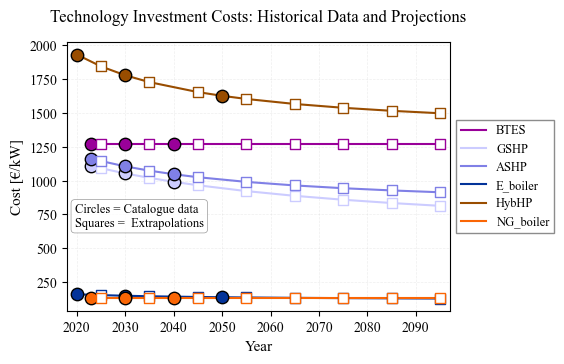


EXTRAPOLATION SUMMARY

Cost Projections (Original + Extrapolated):
year           2020     2023     2025     2030     2035     2040     2045     2050     2055     2065     2075     2085     2095
technology                                                                                                                     
ASHP            NaN 1,163.00 1,144.44 1,105.00 1,073.19 1,047.00 1,025.05      NaN   990.35   964.14   943.65   927.20   913.69
BTES            NaN 1,273.00 1,273.00 1,273.00 1,273.00 1,273.00 1,273.00      NaN 1,273.00 1,273.00 1,273.00 1,273.00 1,273.00
E_boiler     160.00      NaN   153.71   149.00   145.33      NaN   140.00   138.00   136.31   133.60   131.53   129.89   128.57
GSHP            NaN 1,108.00 1,091.09 1,053.00 1,019.95   991.00   965.43      NaN   922.32   887.37   858.47   834.17   813.45
HybHP      1,931.00      NaN 1,843.40 1,778.00 1,727.30      NaN 1,653.83 1,626.36 1,603.15 1,566.09 1,537.80 1,515.49 1,497.46
NG_boiler       NaN   131.00   131.0

In [12]:


# Ensure required columns exist
required_cols = ['technology', 'year', 'cost']
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not found in CSV file")

# Clean data
df = df.dropna(subset=required_cols)

tech_colors = {'NG_boiler':(0.98, 0.4, 0.02),
               'GSHP':    (0.8,0.8,1.0),
               'ASHP':    (0.5,0.5,0.9),
               'E_boiler':(0.01,0.2,0.6),
               'BTES':(0.6,0.0,0.6),
               'HybHP':(0.6,0.3,0.0)}

# Years for extrapolation
extrapolation_years = [2025, 2035, 2045, 2055, 2065, 2075, 2085, 2095]

# Store results
all_results = []

technologies = ['BTES', 'GSHP', 'ASHP', 'E_boiler', 'HybHP', 'NG_boiler']
print(f"Processing {len(technologies)} technologies...")

# ---------------------------------------------------------------------
# Fit model per technology
# ---------------------------------------------------------------------
for tech in technologies:
    tech_data = df[df['technology'] == tech].copy()

    if len(tech_data) < 3:
        print(f"Warning: Technology '{tech}' has less than 3 data points. Skipping...")
        continue

    tech_data = tech_data.sort_values('year')

    x = tech_data['year'].values.astype(float)
    y = tech_data['cost'].values.astype(float)

    # Initial guesses
    a0 = max(y) - min(y)
    b0 = -0.01
    c0 = 0

    try:
        params, _ = curve_fit(
            exp_with_constant,
            x,
            y,
            p0=[a0, b0, c0],
            bounds=([0, -np.inf, 0], [np.inf, np.inf, np.inf]),
            maxfev=10000
        )
    except RuntimeError:
        print(f"Warning: Curve fit failed for '{tech}'. Skipping...")
        continue

    a, b, c = params

    y_pred = exp_with_constant(x, a, b, c)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    print(f"\nTechnology: {tech}")
    print(f"  Fit: y = {c:.4f} + {a:.4f} / (x - ({b:.4f}))")
    print(f"  R-squared: {r_squared:.4f}")

    # Store original data
    for _, row in tech_data.iterrows():
        all_results.append({
            'technology': tech,
            'year': int(row['year']),
            'cost': row['cost'],
            'type': 'original'
        })

    # Extrapolate
    for year in extrapolation_years:
        cost_pred = exp_with_constant(year, a, b, c)
        all_results.append({
            'technology': tech,
            'year': year,
            'cost': max(cost_pred, 0),
            'type': 'extrapolated'
        })

# ---------------------------------------------------------------------
# Save results
# ---------------------------------------------------------------------
results_df = pd.DataFrame(all_results)
# pivot_df.to_csv("extrapolate_technology_cost.csv")
output_file = 'data/inputs/technology_cost_extrapolations.csv'
results_df.to_csv(output_file, index=False)
print(f"\nResults saved to '{output_file}'")

# ---------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------
# ---------------------------------------------------------------------
# Plotting with LaTeX-like styling
# ---------------------------------------------------------------------
import matplotlib
matplotlib.rcParams['text.usetex'] = False  # Set to True if you have LaTeX installed
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']

plt.figure(figsize=(6, 4))
color_map = plt.cm.get_cmap('tab10')

for i, tech in enumerate(technologies):
    tech_data = results_df[results_df['technology'] == tech]
    if tech_data.empty:
        continue

    orig_data = tech_data[tech_data['type'] == 'original']
    extrap_data = tech_data[tech_data['type'] == 'extrapolated']
    all_data = tech_data.sort_values('year')

    # Plot line connecting all points
    plt.plot(
        all_data['year'], all_data['cost'],
        color=tech_colors[tech], linewidth=1.5, 
        label=tech
    )

    # Original data points (circles)
    plt.scatter(
        orig_data['year'], orig_data['cost'],
        color=tech_colors[tech], s=80, marker='o',
        edgecolor='black', linewidth=1.0, zorder=5
    )

    # Extrapolated points (squares)
    plt.scatter(
        extrap_data['year'], extrap_data['cost'],
        color='white', s=60, marker='s',
        edgecolor=tech_colors[tech], linewidth=1.0, zorder=5
    )

# Axis labels with LaTeX formatting
plt.xlabel('Year', fontsize=11, fontweight='normal')
plt.ylabel(r'Cost [€/kW]', fontsize=11, fontweight='normal')  # Euro symbol

# Title without bold for LaTeX style
plt.title('Technology Investment Costs: Historical Data and Projections', 
          fontsize=12, fontweight='normal', pad=15)

# Grid with subtle styling
plt.grid(True, which='both', alpha=0.2, linestyle='--', linewidth=0.5)

# Legend with cleaner formatting
plt.legend(
    loc='center left', 
    fontsize=9,
    framealpha=0.9,
    edgecolor='gray',
    fancybox=False, bbox_to_anchor=(1, 0.5)
)

# Annotation box with LaTeX-inspired formatting
plt.annotate(
    r'Circles = Catalogue data' + '\n' + r'Squares =  Extrapolations',
    xy=(0.02, 0.4),
    xycoords='axes fraction',
    fontsize=9,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round,pad=0.3',
        facecolor='white',
        edgecolor='gray',
        alpha=0.8,
        linewidth=0.5
    )
)

# Adjust axis limits if needed
current_years = results_df['year'].unique()
plt.xlim(min(current_years) - 2, max(current_years) + 2)

# Tight layout
plt.tight_layout(pad=2.0)

# Save with appropriate naming
plot_file = 'output/design/technology_cost_projections.pdf'
plt.savefig(plot_file, dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
print(f"Publication-quality plot saved to '{plot_file}'")

# Show plot
plt.show()

# ---------------------------------------------------------------------
# Summary table
# ---------------------------------------------------------------------
print("\n" + "=" * 80)
print("EXTRAPOLATION SUMMARY")
print("=" * 80)

pivot_df = results_df.pivot_table(
    index='technology',
    columns='year',
    values='cost',
    aggfunc='first'
)

original_years = sorted([y for y in pivot_df.columns if y < 2025])
extrap_years = sorted([y for y in pivot_df.columns if y >= 2025])
pivot_df = pivot_df.reindex(columns=original_years + extrap_years)

print("\nCost Projections (Original + Extrapolated):")
print(pivot_df.to_string(float_format=lambda x: f"{x:,.2f}" if pd.notnull(x) else ""))